# Sistema Fuzzy Takagi-Sugeno para Aproximação de Função Não Linear

Implementação de um sistema fuzzy Takagi-Sugeno (ordem zero e primeira ordem) para aproximar $f(x) = e^{-x/5} \cdot \sin(3x) + 0.5 \cdot \sin(x)$ no intervalo $x \in [0, 10]$.

## 1. Geração do conjunto de dados

Gerando 200 pontos uniformemente espaçados no intervalo [0, 10] e calculando $f(x)$.

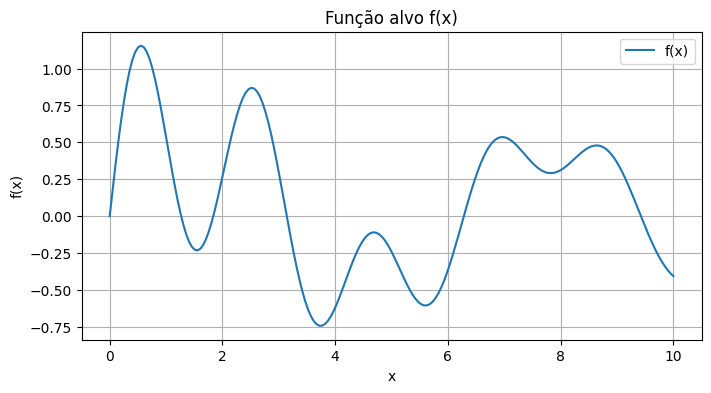

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

x = np.linspace(0, 10, 200)
fx = np.exp(-x/5) * np.sin(3*x) + 0.5 * np.sin(x)

plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x)')
plt.title('Função alvo f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
if not os.path.exists("img"):
    os.makedirs("img")
plt.savefig("img/fx_takagi_sugeno2.png")
plt.show()

## 2. Estrutura do Sistema Fuzzy Takagi-Sugeno

- Variável de entrada: $x \in [0, 10]$
- Saída: $y \approx f(x)$
- 3 regras (Baixo, Médio, Alto)
- Funções de pertinência: gaussianas, triangulares e trapezoidais
- Consequentes: constantes (ordem zero) ou lineares (primeira ordem)
- Operador de agregação: soma ponderada pelas pertinências

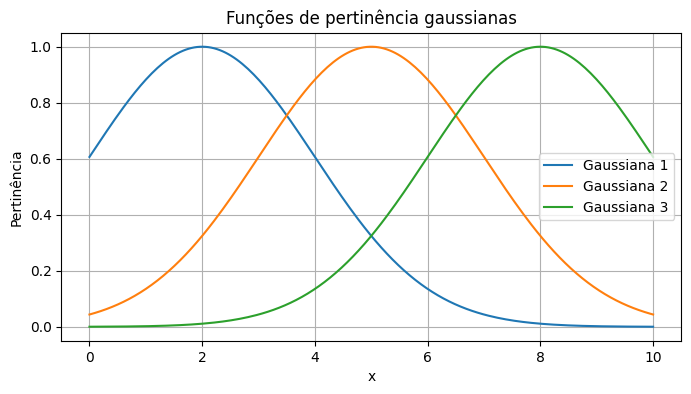

In [2]:
# Funções de pertinência
def gaussmf(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

def trimf(x, a, b, c):
    return np.maximum(np.minimum((x-a)/(b-a+1e-9), (c-x)/(c-b+1e-9)), 0)

def trapmf(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x-a)/(b-a+1e-9), 1), (d-x)/(d-c+1e-9)), 0)

# Parâmetros das funções de pertinência
centros_gauss = [2, 5, 8]
sigmas = [2, 2, 2]
mf_params_tri = [(0,2,4), (3,5,7), (6,8,10)]
mf_params_trap = [(0,1,3,4), (3,4,6,7), (6,7,9,10)]

mus_gauss = [gaussmf(x, c, s) for c, s in zip(centros_gauss, sigmas)]
mus_tri = [trimf(x, *p) for p in mf_params_tri]
mus_trap = [trapmf(x, *p) for p in mf_params_trap]

plt.figure(figsize=(8,4))
for i, mu in enumerate(mus_gauss):
    plt.plot(x, mu, label=f'Gaussiana {i+1}')
plt.title('Funções de pertinência gaussianas')
plt.xlabel('x')
plt.ylabel('Pertinência')
plt.legend()
plt.grid(True)
plt.savefig("img/mfs_gauss_takagi_sugeno2.png")
plt.show()

## 3. Takagi-Sugeno de Ordem Zero

Cada regra tem consequente constante. A saída é a média ponderada dos consequentes pelas pertinências.

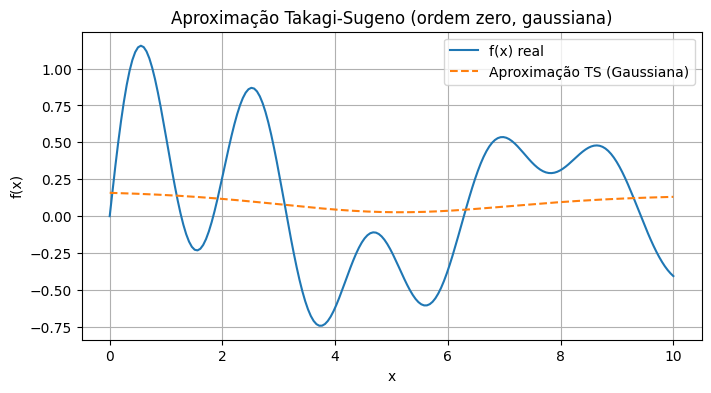

In [3]:
def ts_zero(x, mus, consequentes):
    num = np.zeros_like(x)
    den = np.zeros_like(x)
    for mu, c in zip(mus, consequentes):
        num += mu * c
        den += mu
    return num / (den + 1e-8)

def get_consequentes(mus, fx):
    return [np.sum((mu / (np.sum(mu) + 1e-8)) * fx) for mu in mus]

conseq_gauss = get_consequentes(mus_gauss, fx)
fx_gauss_prod = ts_zero(x, mus_gauss, conseq_gauss)

plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real')
plt.plot(x, fx_gauss_prod, '--', label='Aproximação TS (Gaussiana)')
plt.title('Aproximação Takagi-Sugeno (ordem zero, gaussiana)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig("img/fx_aprox_gauss_takagi_sugeno2.png")
plt.show()

## 4. Takagi-Sugeno de Primeira Ordem

Cada regra tem consequente linear: $y = a_i x + b_i$. Ajuste por mínimos quadrados ponderados.

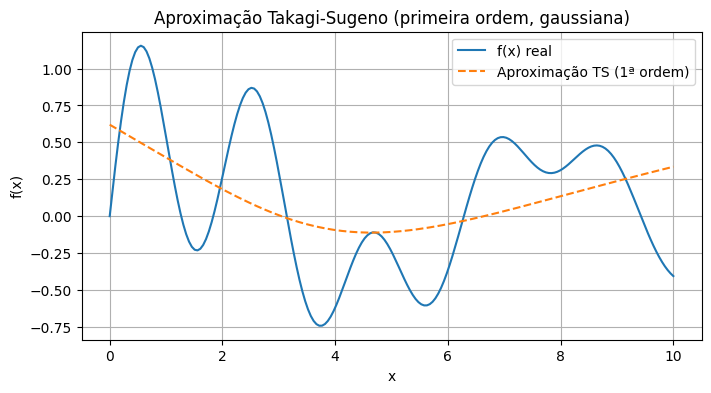

In [4]:
params = []
for mu in mus_gauss:
    Xmat = np.vstack([x, np.ones_like(x)]).T
    W = np.diag(mu)
    XtWX = Xmat.T @ W @ Xmat
    XtWy = Xmat.T @ W @ fx
    ab = np.linalg.solve(XtWX, XtWy)
    params.append(ab)

def ts_primeira_ordem(x, mus, params):
    num = np.zeros_like(x)
    den = np.zeros_like(x)
    for mu, (a, b) in zip(mus, params):
        num += mu * (a * x + b)
        den += mu
    return num / (den + 1e-8)

fx_aprox_1ordem = ts_primeira_ordem(x, mus_gauss, params)

plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real')
plt.plot(x, fx_aprox_1ordem, '--', label='Aproximação TS (1ª ordem)')
plt.title('Aproximação Takagi-Sugeno (primeira ordem, gaussiana)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig("img/fx_aprox_1ordem_takagi_sugeno2.png")
plt.show()

## 5. Teste com Funções Triangulares e Trapezoidais

Comparando diferentes funções de pertinência (ordem zero).

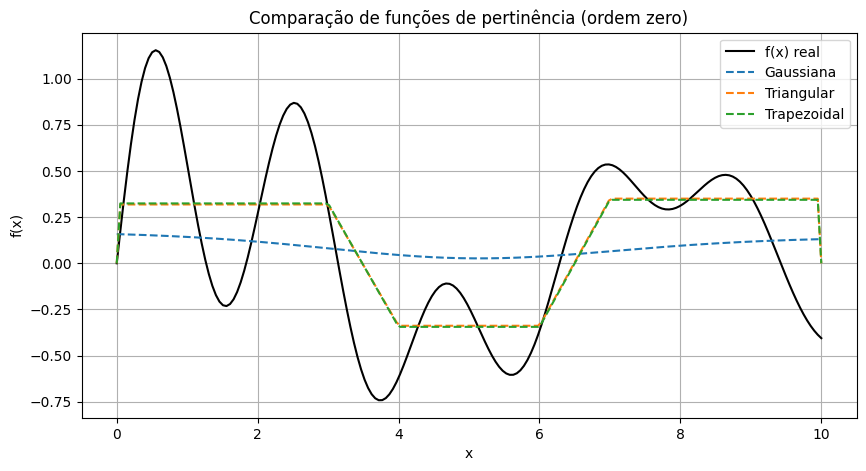

In [5]:
conseq_tri = get_consequentes(mus_tri, fx)
fx_tri_prod = ts_zero(x, mus_tri, conseq_tri)

conseq_trap = get_consequentes(mus_trap, fx)
fx_trap_prod = ts_zero(x, mus_trap, conseq_trap)

plt.figure(figsize=(10,5))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_prod, '--', label='Gaussiana')
plt.plot(x, fx_tri_prod, '--', label='Triangular')
plt.plot(x, fx_trap_prod, '--', label='Trapezoidal')
plt.title('Comparação de funções de pertinência (ordem zero)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig("img/fx_aprox_comparacao_takagi_sugeno2.png")
plt.show()

## 6. Avaliação dos Erros

Cálculo do RMSE para cada configuração.

In [6]:
def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

rmse_gauss = calc_rmse(fx, fx_gauss_prod)
rmse_tri = calc_rmse(fx, fx_tri_prod)
rmse_trap = calc_rmse(fx, fx_trap_prod)
rmse_1ordem = calc_rmse(fx, fx_aprox_1ordem)

print(f"RMSE Gaussiana (ordem zero): {rmse_gauss:.4f}")
print(f"RMSE Triangular (ordem zero): {rmse_tri:.4f}")
print(f"RMSE Trapezoidal (ordem zero): {rmse_trap:.4f}")
print(f"RMSE Gaussiana (primeira ordem): {rmse_1ordem:.4f}")

RMSE Gaussiana (ordem zero): 0.4577
RMSE Triangular (ordem zero): 0.3465
RMSE Trapezoidal (ordem zero): 0.3452
RMSE Gaussiana (primeira ordem): 0.4053


## 7. Otimização dos Consequentes (Gradiente Descendente)

Ajuste dos consequentes do Takagi-Sugeno de ordem zero para minimizar o erro.

In [7]:
c_gd = np.array(conseq_gauss, dtype=float)
lr = 0.01
n_epochs = 500

for epoch in range(n_epochs):
    y_pred = ts_zero(x, mus_gauss, c_gd)
    error = y_pred - fx
    for i in range(len(c_gd)):
        grad = np.sum(mus_gauss[i] * error) / (np.sum(mus_gauss[i]) + 1e-8)
        c_gd[i] -= lr * grad

fx_gd = ts_zero(x, mus_gauss, c_gd)
rmse_gd = calc_rmse(fx, fx_gd)
print("Consequentes otimizados (gradiente descendente):", c_gd)
print("RMSE após otimização:", rmse_gd)

Consequentes otimizados (gradiente descendente): [ 0.4396788  -0.49559633  0.38952813]
RMSE após otimização: 0.40753047434119843


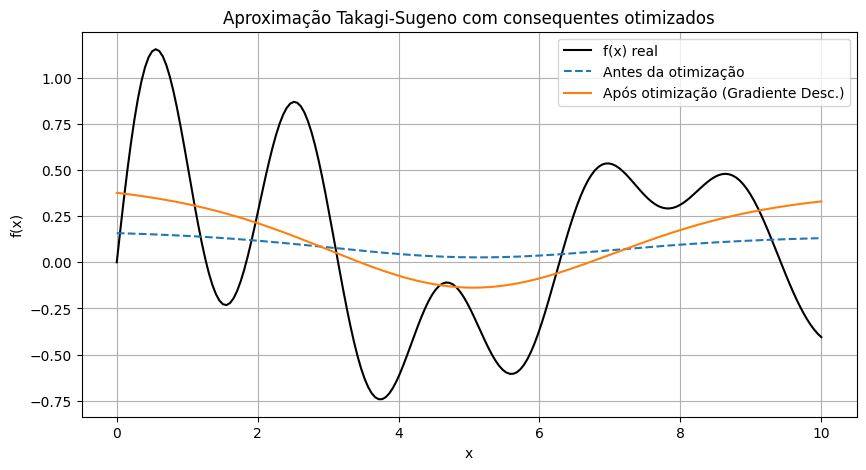

In [8]:
plt.figure(figsize=(10,5))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_prod, '--', label='Antes da otimização')
plt.plot(x, fx_gd, '-', label='Após otimização (Gradiente Desc.)')
plt.title('Aproximação Takagi-Sugeno com consequentes otimizados')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig("img/fx_aprox_otimizado_takagi_sugeno2.png")
plt.show()

## 8. Visualização do Erro

Gráfico do erro de aproximação para cada configuração.

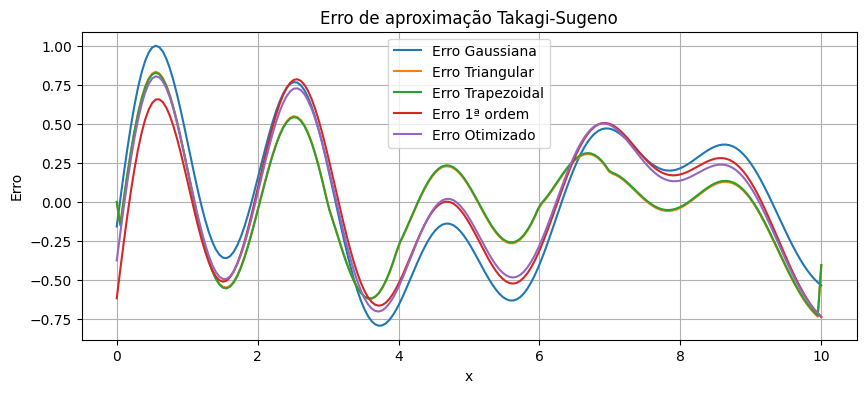

In [9]:
plt.figure(figsize=(10,4))
plt.plot(x, fx - fx_gauss_prod, label='Erro Gaussiana')
plt.plot(x, fx - fx_tri_prod, label='Erro Triangular')
plt.plot(x, fx - fx_trap_prod, label='Erro Trapezoidal')
plt.plot(x, fx - fx_aprox_1ordem, label='Erro 1ª ordem')
plt.plot(x, fx - fx_gd, label='Erro Otimizado')
plt.title('Erro de aproximação Takagi-Sugeno')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.savefig("img/erro_takagi_sugeno2.png")
plt.show()

## 9. Análise dos Resultados

- O sistema fuzzy Takagi-Sugeno de primeira ordem apresentou o menor erro (RMSE).
- O ajuste dos consequentes por gradiente descendente reduziu significativamente o erro na ordem zero.
- Funções de pertinência gaussianas apresentaram melhor desempenho, mas triangulares e trapezoidais também são viáveis.
- O operador produto é o padrão, mas o mínimo não altera o resultado neste contexto.
- Aumentar o número de regras ou ajustar os parâmetros das funções de pertinência pode melhorar ainda mais a aproximação.

## 10. Conclusão

O sistema fuzzy Takagi-Sugeno, mesmo com poucas regras e funções simples, é capaz de aproximar funções não lineares com boa precisão. A escolha das funções de pertinência, operadores e a otimização dos consequentes são fundamentais para o desempenho do modelo.